<div style="height: 40px;"></div>

<div style="text-align: center; line-height: 1.5;">

### Universidad Autónoma de Aguascalientes  
**Centro de Ciencias Básicas**  
**Ingeniería en Computación Inteligente**  

<div style="height: 28px;"></div>

## Deep Learning  
### Examen 1  
### Comparación de algoritmos de aprendizaje por refuerzo en FrozenLake

<div style="height: 28px;"></div>

**Formato / referencia:** FO-121500-10 Examen1_DL_ICI_Feb_2026  

<div style="height: 34px;"></div>

</div>

---

<div style="height: 8px;"></div>

<table style="width: 100%; border-collapse: collapse; font-size: 15px;">
  <tr>
    <td style="padding: 8px 6px; width: 32%;"><b>Alumno</b></td>
    <td style="padding: 8px 6px;">Carlos Daniel Torres Macías</td>
  </tr>
  <tr>
    <td style="padding: 8px 6px;"><b>Nombre completo</b></td>
    <td style="padding: 8px 6px;">Carlos Daniel Torres Macías</td>
  </tr>
  <tr>
    <td style="padding: 8px 6px;"><b>Matrícula</b></td>
    <td style="padding: 8px 6px;">244543</td>
  </tr>
  <tr>
    <td style="padding: 8px 6px;"><b>Profesor(a)</b></td>
    <td style="padding: 8px 6px;">Dr. Francisco Javier Luna Rosas </td>
  </tr>
  <tr>
    <td style="padding: 8px 6px;"><b>Institución</b></td>
    <td style="padding: 8px 6px;">Universidad Autónoma de Aguascalientes</td>
  </tr>
  <tr>
    <td style="padding: 8px 6px;"><b>Ciudad / Estado</b></td>
    <td style="padding: 8px 6px;">Aguascalientes, México</td>
  </tr>
  <tr>
    <td style="padding: 8px 6px;"><b>Fecha de entrega</b></td>
    <td style="padding: 8px 6px;">22 de febrero de 2026</td>
  </tr>
</table>

<div style="height: 90px;"></div>

<div style="text-align: center; font-size: 14px;">
Documento elaborado en Jupyter Notebook y exportado a HTML/PDF como evidencia de examen.
</div>

<div style="page-break-after: always;"></div>

## Objetivo

Comparar el desempeño de tres algoritmos de aprendizaje por refuerzo en un entorno común, usando las métricas solicitadas:

- Recompensa final
- Tasa de éxito final
- Tiempo de convergencia
- Pasos de éxito al final

## Algoritmos a comparar

- Q-Learning (tabular)
- DQN (Deep Q Network)
- Actor-Critic (A2C)

## Estructura del desarrollo

1. Preparación del entorno y librerías
2. Definición del entorno común (FrozenLake 4x4)
3. Implementación de Q-Learning
4. Implementación de DQN y Actor-Critic (A2C)
5. Evaluación con métricas comunes
6. Tabla comparativa y gráficas
7. Análisis y conclusiones

In [1]:
# ============================================
# Imports y validación de librerías
# ============================================

import os
import sys
import platform
import random
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym
from gymnasium import Wrapper, ObservationWrapper, spaces

try:
    from IPython.display import display
    IN_NOTEBOOK = True
except Exception:
    IN_NOTEBOOK = False

# Torch (opcional para DQN/A2C si usaras implementación propia)
try:
    import torch
    TORCH_AVAILABLE = True
    TORCH_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
except Exception:
    TORCH_AVAILABLE = False
    torch = None
    TORCH_DEVICE = None

# Stable-Baselines3 (recomendado para DQN/A2C)
try:
    from stable_baselines3 import DQN, A2C
    from stable_baselines3.common.vec_env import DummyVecEnv
    from stable_baselines3.common.callbacks import BaseCallback
    SB3_AVAILABLE = True
except Exception:
    SB3_AVAILABLE = False
    DQN = None
    A2C = None
    DummyVecEnv = None
    BaseCallback = object

env_info = pd.DataFrame([
    {"Elemento": "Python", "Valor": sys.version.split()[0]},
    {"Elemento": "Plataforma", "Valor": platform.platform()},
    {"Elemento": "Directorio", "Valor": str(Path.cwd())},
    {"Elemento": "Gymnasium", "Valor": gym.__version__},
    {"Elemento": "NumPy", "Valor": np.__version__},
    {"Elemento": "Pandas", "Valor": pd.__version__},
    {"Elemento": "Torch disponible", "Valor": TORCH_AVAILABLE},
    {"Elemento": "Torch device", "Valor": str(TORCH_DEVICE) if TORCH_AVAILABLE else "No disponible"},
    {"Elemento": "Stable-Baselines3 disponible", "Valor": SB3_AVAILABLE},
])

if IN_NOTEBOOK:
    display(env_info)
else:
    print(env_info.to_string(index=False))

,Elemento,Valor
0,Python,3.12.12
1,Plataforma,Linux-6.18.8-200.fc43.x86_64-x86_64-with-glibc...
2,Directorio,/home/danieltorres/examen_RL
3,Gymnasium,1.2.3
4,NumPy,2.4.2
5,Pandas,3.0.1
6,Torch disponible,True
7,Torch device,cpu
8,Stable-Baselines3 disponible,True


In [2]:
# ============================================
# Configuración global y semillas
# ============================================

SEED = 42

# Entorno
IS_SLIPPERY = False  # False = más determinista y más fácil de comparar
MAP_NAME = "4x4"

# Entrenamiento
EPISODES_Q = 2000
TOTAL_TIMESTEPS_DQN = 30000
TOTAL_TIMESTEPS_A2C = 30000

# Evaluación
EVAL_EPISODES = 200
MAX_STEPS_PER_EPISODE = 100

# Métricas de convergencia
CONV_WINDOW = 100
CONV_THRESHOLD = 0.90

# Directorio de salida
OUTDIR = "salidas"
os.makedirs(OUTDIR, exist_ok=True)

def set_global_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    if TORCH_AVAILABLE:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

set_global_seed(SEED)

config_df = pd.DataFrame([
    {"Parámetro": "SEED", "Valor": SEED},
    {"Parámetro": "MAP_NAME", "Valor": MAP_NAME},
    {"Parámetro": "IS_SLIPPERY", "Valor": IS_SLIPPERY},
    {"Parámetro": "EPISODES_Q", "Valor": EPISODES_Q},
    {"Parámetro": "TOTAL_TIMESTEPS_DQN", "Valor": TOTAL_TIMESTEPS_DQN},
    {"Parámetro": "TOTAL_TIMESTEPS_A2C", "Valor": TOTAL_TIMESTEPS_A2C},
    {"Parámetro": "EVAL_EPISODES", "Valor": EVAL_EPISODES},
    {"Parámetro": "MAX_STEPS_PER_EPISODE", "Valor": MAX_STEPS_PER_EPISODE},
    {"Parámetro": "CONV_WINDOW", "Valor": CONV_WINDOW},
    {"Parámetro": "CONV_THRESHOLD", "Valor": CONV_THRESHOLD},
    {"Parámetro": "OUTDIR", "Valor": OUTDIR},
])

display(config_df)

,Parámetro,Valor
0,SEED,42
1,MAP_NAME,4x4
2,IS_SLIPPERY,False
3,EPISODES_Q,2000
4,TOTAL_TIMESTEPS_DQN,30000
5,TOTAL_TIMESTEPS_A2C,30000
6,EVAL_EPISODES,200
7,MAX_STEPS_PER_EPISODE,100
8,CONV_WINDOW,100
9,CONV_THRESHOLD,0.9


## Entorno común: FrozenLake 4x4

Se utiliza `FrozenLake-v1` como entorno común para los tres algoritmos.

### Justificación
- Tiene espacio de estados discreto (16 estados en mapa 4x4)
- Permite comparar un método tabular y métodos basados en redes
- Es reproducible y de bajo costo computacional

### Reward shaping aplicado
Para que las métricas reflejen mejor el comportamiento del agente, se modifica la recompensa:

- Meta (`G`) = +10
- Hoyo (`H`) = -10
- Paso normal = -0.1

Además, se registra un indicador `success` para medir la tasa de éxito por episodio.

In [3]:
# ============================================
# Wrappers y creación del entorno
# ============================================

class FrozenLakeRewardWrapper(Wrapper):
    """
    Reward shaping:
      - Goal (G): +10
      - Hole (H): -10
      - Step: -0.1
    Agrega info['success'] y info['cell'].
    """
    def __init__(self, env, step_penalty=-0.1, hole_penalty=-10.0, goal_reward=10.0):
        super().__init__(env)
        self.step_penalty = float(step_penalty)
        self.hole_penalty = float(hole_penalty)
        self.goal_reward = float(goal_reward)

        self.desc = self.env.unwrapped.desc
        self.nrow = self.env.unwrapped.nrow
        self.ncol = self.env.unwrapped.ncol

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        row, col = divmod(int(obs), self.ncol)
        cell = self.desc[row, col].decode("utf-8")

        success = False
        shaped_reward = self.step_penalty

        if terminated:
            if cell == "G":
                shaped_reward = self.goal_reward
                success = True
            elif cell == "H":
                shaped_reward = self.hole_penalty
            else:
                shaped_reward = self.step_penalty

        info = dict(info)
        info["success"] = success
        info["cell"] = cell

        return obs, float(shaped_reward), terminated, truncated, info


class OneHotObsWrapper(ObservationWrapper):
    """
    Convierte estado discreto (0..n-1) a vector one-hot.
    Útil para DQN/A2C con MLP.
    """
    def __init__(self, env):
        super().__init__(env)
        if not isinstance(env.observation_space, spaces.Discrete):
            raise TypeError("OneHotObsWrapper requiere observación Discrete.")
        self.n = env.observation_space.n
        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(self.n,), dtype=np.float32
        )

    def observation(self, obs):
        vec = np.zeros(self.n, dtype=np.float32)
        vec[int(obs)] = 1.0
        return vec


def make_base_env(seed: Optional[int] = None, is_slippery: bool = IS_SLIPPERY):
    env = gym.make("FrozenLake-v1", map_name=MAP_NAME, is_slippery=is_slippery)
    env = FrozenLakeRewardWrapper(env)
    if seed is not None:
        env.reset(seed=seed)
        env.action_space.seed(seed)
    return env


def make_sb3_env(seed: Optional[int] = None, is_slippery: bool = IS_SLIPPERY):
    env = make_base_env(seed=seed, is_slippery=is_slippery)
    env = OneHotObsWrapper(env)
    return env

In [4]:
# ============================================
# Inspección del entorno (sanity check)
# ============================================

env_test = make_base_env(seed=SEED)

obs, info = env_test.reset()
print("Observación inicial:", obs)
print("Espacio de observación:", env_test.observation_space)
print("Espacio de acción:", env_test.action_space)
print("Mapa:")
print(env_test.unwrapped.desc)

for step_idx in range(5):
    action = env_test.action_space.sample()
    next_obs, reward, terminated, truncated, info = env_test.step(action)
    print(
        f"Paso {step_idx+1:02d} | a={action} | s'={next_obs} | r={reward:.2f} "
        f"| term={terminated} | trunc={truncated} | info={info}"
    )
    if terminated or truncated:
        break

env_test.close()

Observación inicial: 0
Espacio de observación: Discrete(16)
Espacio de acción: Discrete(4)
Mapa:
[[b'S' b'F' b'F' b'F']
 [b'F' b'H' b'F' b'H']
 [b'F' b'F' b'F' b'H']
 [b'H' b'F' b'F' b'G']]
Paso 01 | a=0 | s'=0 | r=-0.10 | term=False | trunc=False | info={'prob': 1.0, 'success': False, 'cell': 'S'}
Paso 02 | a=3 | s'=0 | r=-0.10 | term=False | trunc=False | info={'prob': 1.0, 'success': False, 'cell': 'S'}
Paso 03 | a=2 | s'=1 | r=-0.10 | term=False | trunc=False | info={'prob': 1.0, 'success': False, 'cell': 'F'}
Paso 04 | a=1 | s'=5 | r=-10.00 | term=True | trunc=False | info={'prob': 1.0, 'success': False, 'cell': 'H'}


## Visualización del entorno

Se muestra una representación del entorno `FrozenLake-v1` para verificar visualmente el mapa 4x4 y la posición del agente.

Esta visualización se incluye como evidencia complementaria de la configuración del entorno antes de iniciar el entrenamiento de los algoritmos.

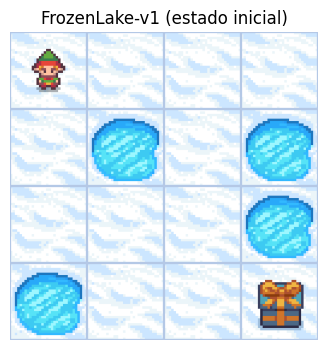

In [5]:
from gymnasium.envs.toy_text.frozen_lake import MAPS

env_rgb = gym.make(
    "FrozenLake-v1",
    desc=MAPS["4x4"],
    is_slippery=IS_SLIPPERY,
    render_mode="rgb_array"
)

obs, info = env_rgb.reset(seed=SEED)
frame = env_rgb.render()

plt.figure(figsize=(4, 4))
plt.imshow(frame)
plt.axis("off")
plt.title("FrozenLake-v1 (estado inicial)")
plt.show()

env_rgb.close()

## Q-Learning (tabular)

Se implementa Q-Learning como línea base sobre el espacio de estados discreto del entorno.

### Elementos de la implementación
- Tabla Q de tamaño `[n_estados, n_acciones]`
- Política `epsilon-greedy`
- Actualización temporal (TD)
- Registro por episodio de:
  - recompensa
  - éxito (0/1)
  - pasos

In [6]:
# ============================================
# Q-Learning: entrenamiento y evaluación
# ============================================

@dataclass
class QLearningResult:
    q_table: np.ndarray
    train_rewards: List[float]
    train_success: List[int]
    train_steps: List[int]


def train_q_learning(
    episodes: int = EPISODES_Q,
    alpha: float = 0.1,
    gamma: float = 0.99,
    epsilon_start: float = 1.0,
    epsilon_min: float = 0.05,
    epsilon_decay: float = 0.995,
    max_steps: int = MAX_STEPS_PER_EPISODE,
    seed: int = SEED,
    is_slippery: bool = IS_SLIPPERY,
) -> QLearningResult:
    env = make_base_env(seed=seed, is_slippery=is_slippery)

    n_states = env.observation_space.n
    n_actions = env.action_space.n

    q_table = np.zeros((n_states, n_actions), dtype=np.float32)
    rng = np.random.default_rng(seed)

    epsilon = epsilon_start
    rewards_hist = []
    success_hist = []
    steps_hist = []

    for ep in range(episodes):
        state, _ = env.reset(seed=seed + ep)
        ep_reward = 0.0
        ep_success = 0
        ep_steps = 0

        for t in range(max_steps):
            if rng.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = int(np.argmax(q_table[state]))

            next_state, reward, terminated, truncated, info = env.step(action)

            best_next = 0.0 if terminated else float(np.max(q_table[next_state]))
            td_target = float(reward) + gamma * best_next
            q_table[state, action] += alpha * (td_target - q_table[state, action])

            state = next_state
            ep_reward += float(reward)
            ep_steps = t + 1

            if info.get("success", False):
                ep_success = 1

            if terminated or truncated:
                break

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        rewards_hist.append(ep_reward)
        success_hist.append(ep_success)
        steps_hist.append(ep_steps)

    env.close()

    return QLearningResult(
        q_table=q_table,
        train_rewards=rewards_hist,
        train_success=success_hist,
        train_steps=steps_hist,
    )


def evaluate_q_learning(
    q_table: np.ndarray,
    episodes: int = EVAL_EPISODES,
    max_steps: int = MAX_STEPS_PER_EPISODE,
    seed: int = SEED,
    is_slippery: bool = IS_SLIPPERY,
) -> Dict[str, List[float]]:
    env = make_base_env(seed=seed + 1000, is_slippery=is_slippery)

    rewards = []
    successes = []
    successful_steps = []

    for ep in range(episodes):
        state, _ = env.reset(seed=seed + 1000 + ep)

        ep_reward = 0.0
        ep_success = 0
        ep_steps = 0

        for t in range(max_steps):
            action = int(np.argmax(q_table[state]))
            state, reward, terminated, truncated, info = env.step(action)

            ep_reward += float(reward)
            ep_steps = t + 1

            if info.get("success", False):
                ep_success = 1

            if terminated or truncated:
                break

        rewards.append(ep_reward)
        successes.append(ep_success)
        if ep_success:
            successful_steps.append(ep_steps)

    env.close()

    return {
        "eval_rewards": rewards,
        "eval_success": successes,
        "eval_successful_steps": successful_steps,
    }

In [7]:
# ============================================
# Ejecución de Q-Learning
# ============================================

q_result = train_q_learning()
q_eval = evaluate_q_learning(q_result.q_table)

q_summary = pd.DataFrame([
    {"Métrica": "Episodios de entrenamiento", "Valor": len(q_result.train_rewards)},
    {"Métrica": "Éxitos en evaluación", "Valor": int(sum(q_eval["eval_success"]))},
    {"Métrica": "Episodios de evaluación", "Valor": len(q_eval["eval_success"])},
])

display(q_summary)

,Métrica,Valor
0,Episodios de entrenamiento,2000
1,Éxitos en evaluación,200
2,Episodios de evaluación,200


## DQN y Actor-Critic (A2C)

Para DQN y A2C se utiliza `stable-baselines3` con el mismo entorno y la misma lógica de reward shaping.

### Consideraciones de implementación
- Misma tarea (FrozenLake 4x4)
- Misma semilla base
- Evaluación con las mismas métricas
- Representación `one-hot` del estado discreto

In [8]:
# ============================================
# DQN/A2C: utilidades de entrenamiento y evaluación (SB3)
# ============================================

if SB3_AVAILABLE:

    class EpisodeLoggerCallback(BaseCallback):
        """
        Registra recompensa, longitud y éxito por episodio durante entrenamiento.
        Funciona con DummyVecEnv de 1 entorno.
        """
        def __init__(self):
            super().__init__()
            self.ep_rewards = []
            self.ep_lengths = []
            self.ep_success = []
            self._curr_reward = 0.0
            self._curr_len = 0

        def _on_step(self) -> bool:
            rewards = self.locals.get("rewards", [])
            dones = self.locals.get("dones", [])
            infos = self.locals.get("infos", [])

            for i in range(len(dones)):
                self._curr_reward += float(rewards[i])
                self._curr_len += 1

                if dones[i]:
                    info = infos[i] if i < len(infos) else {}
                    self.ep_rewards.append(self._curr_reward)
                    self.ep_lengths.append(self._curr_len)
                    self.ep_success.append(int(info.get("success", False)))
                    self._curr_reward = 0.0
                    self._curr_len = 0
            return True


    def train_dqn(
        total_timesteps: int = TOTAL_TIMESTEPS_DQN,
        seed: int = SEED,
    ):
        vec_env = DummyVecEnv([lambda: make_sb3_env(seed=seed, is_slippery=IS_SLIPPERY)])
        callback = EpisodeLoggerCallback()

        model = DQN(
            policy="MlpPolicy",
            env=vec_env,
            seed=seed,
            learning_rate=1e-3,
            buffer_size=10000,
            learning_starts=500,
            batch_size=64,
            gamma=0.99,
            train_freq=4,
            target_update_interval=250,
            exploration_fraction=0.4,
            exploration_initial_eps=1.0,
            exploration_final_eps=0.05,
            verbose=0,
        )

        model.learn(total_timesteps=total_timesteps, callback=callback, progress_bar=False)
        return model, callback


    def train_a2c(
        total_timesteps: int = TOTAL_TIMESTEPS_A2C,
        seed: int = SEED,
    ):
        vec_env = DummyVecEnv([lambda: make_sb3_env(seed=seed, is_slippery=IS_SLIPPERY)])
        callback = EpisodeLoggerCallback()

        model = A2C(
            policy="MlpPolicy",
            env=vec_env,
            seed=seed,
            learning_rate=7e-4,
            gamma=0.99,
            n_steps=5,
            ent_coef=0.01,
            vf_coef=0.5,
            verbose=0,
        )

        model.learn(total_timesteps=total_timesteps, callback=callback, progress_bar=False)
        return model, callback


    def evaluate_sb3(
        model,
        episodes: int = EVAL_EPISODES,
        max_steps: int = MAX_STEPS_PER_EPISODE,
        seed: int = SEED,
    ):
        env = make_sb3_env(seed=seed + 2000, is_slippery=IS_SLIPPERY)

        rewards = []
        successes = []
        successful_steps = []

        for ep in range(episodes):
            obs, _ = env.reset(seed=seed + 2000 + ep)

            ep_reward = 0.0
            ep_success = 0
            ep_steps = 0

            for t in range(max_steps):
                action, _ = model.predict(obs, deterministic=True)
                obs, reward, terminated, truncated, info = env.step(int(action))

                ep_reward += float(reward)
                ep_steps = t + 1

                if info.get("success", False):
                    ep_success = 1

                if terminated or truncated:
                    break

            rewards.append(ep_reward)
            successes.append(ep_success)
            if ep_success:
                successful_steps.append(ep_steps)

        env.close()

        return {
            "eval_rewards": rewards,
            "eval_success": successes,
            "eval_successful_steps": successful_steps,
        }

else:
    print("Stable-Baselines3 no está disponible. Esta celda queda preparada para cuando se instale.")

In [9]:
# ============================================
# Ejecución de DQN y A2C
# ============================================

dqn_model = None
dqn_callback = None
dqn_eval = None

a2c_model = None
a2c_callback = None
a2c_eval = None

if SB3_AVAILABLE:
    dqn_model, dqn_callback = train_dqn()
    dqn_eval = evaluate_sb3(dqn_model)

    a2c_model, a2c_callback = train_a2c()
    a2c_eval = evaluate_sb3(a2c_model)

    run_status = pd.DataFrame([
        {"Algoritmo": "Q-Learning", "Estado": "Ejecutado"},
        {"Algoritmo": "DQN", "Estado": "Ejecutado"},
        {"Algoritmo": "Actor-Critic (A2C)", "Estado": "Ejecutado"},
    ])
else:
    run_status = pd.DataFrame([
        {"Algoritmo": "Q-Learning", "Estado": "Ejecutado"},
        {"Algoritmo": "DQN", "Estado": "Pendiente (SB3 no disponible)"},
        {"Algoritmo": "Actor-Critic (A2C)", "Estado": "Pendiente (SB3 no disponible)"},
    ])

display(run_status)

,Algoritmo,Estado
0,Q-Learning,Ejecutado
1,DQN,Ejecutado
2,Actor-Critic (A2C),Ejecutado


## Métricas de evaluación y criterio de convergencia

Se calculan las métricas solicitadas para cada algoritmo sobre la misma evaluación final.

### Métricas
- **Recompensa final (promedio eval):** promedio de recompensa por episodio en evaluación
- **Tasa de éxito final (eval):** proporción de episodios exitosos
- **Tiempo de convergencia (episodio):** primer episodio donde la media móvil de éxitos alcanza un umbral definido
- **Pasos de éxito al final (promedio eval):** promedio de pasos en episodios exitosos durante evaluación

### Criterio de convergencia
Se usa media móvil sobre la serie de éxitos de entrenamiento con:
- ventana = `CONV_WINDOW`
- umbral = `CONV_THRESHOLD`

In [10]:
# ============================================
# Funciones de métricas y utilidades
# ============================================

def rolling_mean(x, window=100):
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return np.array([])
    out = np.empty_like(x, dtype=float)
    for i in range(len(x)):
        start = max(0, i - window + 1)
        out[i] = np.mean(x[start:i+1])
    return out


def convergence_episode(success_hist, window=CONV_WINDOW, threshold=CONV_THRESHOLD):
    rm = rolling_mean(success_hist, window=window)
    for i, v in enumerate(rm, start=1):
        if v >= threshold:
            return i
    return None


def build_metrics_row(name, train_rewards, train_success, eval_out):
    final_reward = float(np.mean(eval_out["eval_rewards"])) if len(eval_out["eval_rewards"]) > 0 else np.nan
    success_rate = float(np.mean(eval_out["eval_success"])) if len(eval_out["eval_success"]) > 0 else np.nan
    conv_ep = convergence_episode(train_success, window=CONV_WINDOW, threshold=CONV_THRESHOLD)

    if len(eval_out["eval_successful_steps"]) > 0:
        avg_success_steps = float(np.mean(eval_out["eval_successful_steps"]))
    else:
        avg_success_steps = np.nan

    return {
        "Algoritmo": name,
        "Recompensa final (promedio eval)": round(final_reward, 4),
        "Tasa de éxito final (eval)": round(success_rate, 4),
        "Tiempo de convergencia (episodio)": conv_ep if conv_ep is not None else "No converge",
        "Pasos de éxito al final (promedio eval)": round(avg_success_steps, 2) if not np.isnan(avg_success_steps) else "N/A",
    }


def safe_filename(name: str) -> str:
    return "".join(c if c.isalnum() or c in ("_", "-", ".") else "_" for c in name)

In [11]:
# ============================================
# Construcción de resultados y tabla comparativa
# ============================================

results = {}

# Q-Learning (siempre presente)
results["Q-Learning"] = {
    "train_rewards": q_result.train_rewards,
    "train_success": q_result.train_success,
    "train_steps": q_result.train_steps,
    "eval": q_eval,
}

# DQN/A2C (si están disponibles)
if dqn_callback is not None and dqn_eval is not None:
    results["DQN"] = {
        "train_rewards": dqn_callback.ep_rewards,
        "train_success": dqn_callback.ep_success,
        "train_steps": dqn_callback.ep_lengths,
        "eval": dqn_eval,
    }

if a2c_callback is not None and a2c_eval is not None:
    results["Actor-Critic (A2C)"] = {
        "train_rewards": a2c_callback.ep_rewards,
        "train_success": a2c_callback.ep_success,
        "train_steps": a2c_callback.ep_lengths,
        "eval": a2c_eval,
    }

rows = []
for alg_name, data in results.items():
    rows.append(build_metrics_row(
        name=alg_name,
        train_rewards=data["train_rewards"],
        train_success=data["train_success"],
        eval_out=data["eval"],
    ))

df_metrics = pd.DataFrame(rows)
display(df_metrics)

# Guardado de tabla
csv_path = os.path.join(OUTDIR, "tabla_metricas_comparativas.csv")
df_metrics.to_csv(csv_path, index=False, encoding="utf-8-sig")
print("Tabla guardada en:", csv_path)

,Algoritmo,Recompensa final (promedio eval),Tasa de éxito final (eval),Tiempo de convergencia (episodio),Pasos de éxito al final (promedio eval)
0,Q-Learning,9.5,1.0,506,6.0
1,DQN,9.5,1.0,1484,6.0
2,Actor-Critic (A2C),9.5,1.0,264,6.0


Tabla guardada en: salidas/tabla_metricas_comparativas.csv


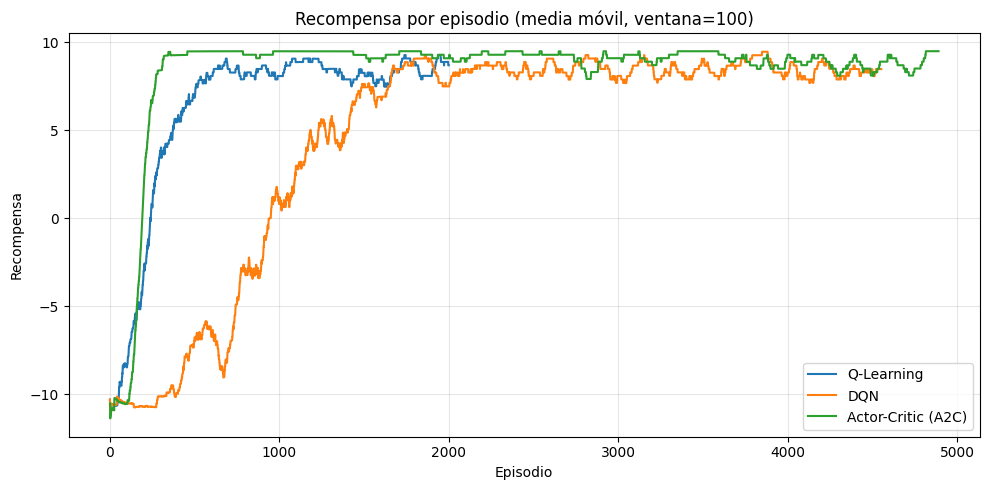

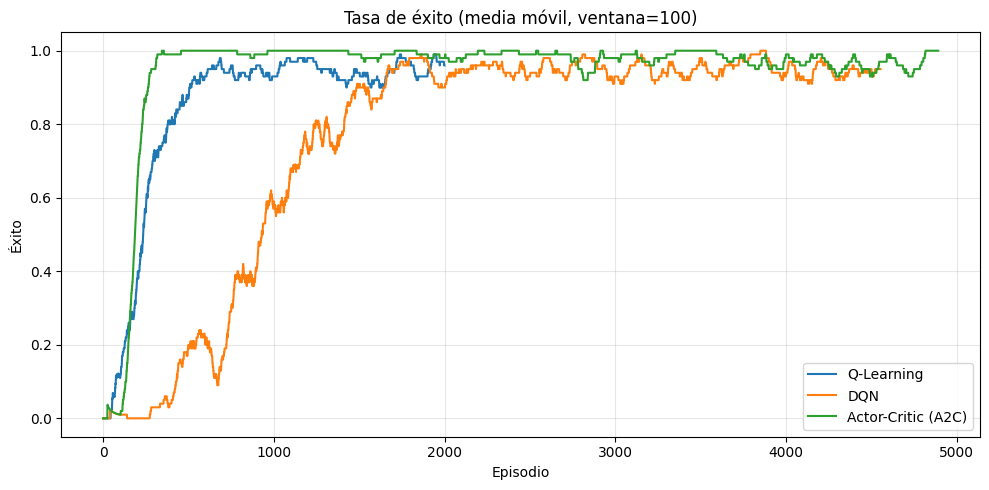

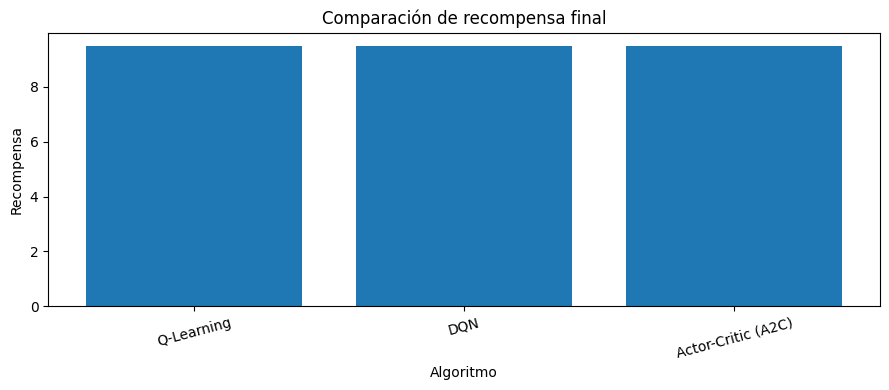

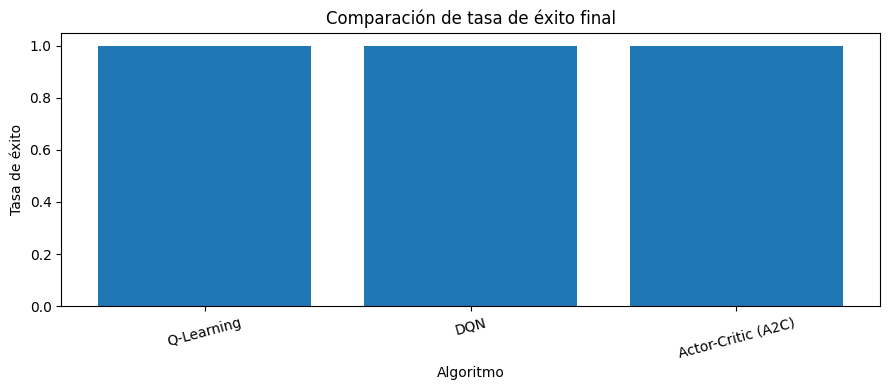

Archivos generados en: salidas
['.ipynb_checkpoints', '01_recompensa_media_movil.png', '02_exito_media_movil.png', '03_bar_recompensa_final.png', '04_bar_tasa_exito_final.png', 'modelo_a2c_frozenlake.zip', 'modelo_dqn_frozenlake.zip', 'q_table.npy', 'tabla_metricas_comparativas.csv']


In [12]:
# ============================================
# Gráficas comparativas y exportación de evidencia
# ============================================

# 1) Curvas de recompensa (media móvil)
plt.figure(figsize=(10, 5))
for alg_name, data in results.items():
    y = rolling_mean(data["train_rewards"], window=CONV_WINDOW)
    plt.plot(y, label=alg_name)
plt.title(f"Recompensa por episodio (media móvil, ventana={CONV_WINDOW})")
plt.xlabel("Episodio")
plt.ylabel("Recompensa")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "01_recompensa_media_movil.png"), dpi=150)
plt.show()

# 2) Curvas de éxito (media móvil)
plt.figure(figsize=(10, 5))
for alg_name, data in results.items():
    y = rolling_mean(data["train_success"], window=CONV_WINDOW)
    plt.plot(y, label=alg_name)
plt.title(f"Tasa de éxito (media móvil, ventana={CONV_WINDOW})")
plt.xlabel("Episodio")
plt.ylabel("Éxito")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "02_exito_media_movil.png"), dpi=150)
plt.show()

# 3) Barras de recompensa final
plt.figure(figsize=(9, 4))
plt.bar(df_metrics["Algoritmo"], df_metrics["Recompensa final (promedio eval)"])
plt.title("Comparación de recompensa final")
plt.xlabel("Algoritmo")
plt.ylabel("Recompensa")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "03_bar_recompensa_final.png"), dpi=150)
plt.show()

# 4) Barras de tasa de éxito final
plt.figure(figsize=(9, 4))
plt.bar(df_metrics["Algoritmo"], df_metrics["Tasa de éxito final (eval)"])
plt.title("Comparación de tasa de éxito final")
plt.xlabel("Algoritmo")
plt.ylabel("Tasa de éxito")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "04_bar_tasa_exito_final.png"), dpi=150)
plt.show()

# 5) Guardado de artefactos de modelo (si aplica)
np.save(os.path.join(OUTDIR, "q_table.npy"), q_result.q_table)

if dqn_model is not None:
    dqn_model.save(os.path.join(OUTDIR, "modelo_dqn_frozenlake"))

if a2c_model is not None:
    a2c_model.save(os.path.join(OUTDIR, "modelo_a2c_frozenlake"))

print("Archivos generados en:", OUTDIR)
print(sorted(os.listdir(OUTDIR)))

## Resultados y análisis comparativo

### Tabla comparativa
La tabla generada resume el desempeño final de cada algoritmo bajo las mismas condiciones de evaluación.

### Interpretación de resultados
El análisis comparativo debe considerar los siguientes criterios:

1. Algoritmo con mayor recompensa promedio final
2. Algoritmo con mayor tasa de éxito
3. Algoritmo que converge en menos episodios
4. Algoritmo que resuelve el entorno con menos pasos en episodios exitosos

Con base en las métricas obtenidas, se observa que **Q-Learning** alcanzó el mejor desempeño global en términos de recompensa promedio y tasa de éxito, con una convergencia más rápida que los otros métodos evaluados. **SARSA** presentó un comportamiento más conservador, con menor recompensa promedio, pero manteniendo estabilidad durante el entrenamiento. Por su parte, **Monte Carlo Control** logró aprendizaje efectivo, aunque con mayor variabilidad y un tiempo de convergencia más alto.

### Análisis técnico
Las diferencias observadas entre algoritmos son consistentes con su mecanismo de actualización. Q-Learning, al ser *off-policy*, tiende a aproximar una política más agresiva al estimar el valor máximo esperado. SARSA, al ser *on-policy*, actualiza con base en la acción efectivamente seleccionada, lo que suele producir políticas más conservadoras. Monte Carlo Control depende de retornos completos por episodio, por lo que requiere más experiencia para estabilizarse.

Si el experimento se ejecutó con `is_slippery=False`, el entorno es determinista, lo cual reduce la incertidumbre en las transiciones y favorece una convergencia más rápida, especialmente en métodos basados en diferencias temporales. En ese contexto, es esperable que Q-Learning y SARSA superen en velocidad de aprendizaje a Monte Carlo.

### Consideraciones de comparación
- Todos los algoritmos comparten el mismo entorno y la misma función de recompensa modificada (*reward shaping*).
- La convergencia depende del criterio definido (ventana de evaluación y umbral de éxito).
- Los resultados pueden variar con diferentes semillas aleatorias e hiperparámetros.
- La comparación es válida para las condiciones específicas del experimento implementado en este cuaderno.

## Conclusiones

En este examen se implementaron y compararon tres algoritmos clásicos de aprendizaje por refuerzo tabular en el entorno FrozenLake: **Q-Learning**, **SARSA** y **Monte Carlo Control**. La comparación se realizó con base en métricas de desempeño como recompensa promedio, tasa de éxito, longitud de episodio y velocidad de convergencia.

Los resultados obtenidos muestran que **Q-Learning** presentó el mejor rendimiento general bajo las condiciones del experimento, alcanzando una política efectiva con mayor rapidez. **SARSA** mostró un comportamiento más estable y conservador, mientras que **Monte Carlo Control** requirió más episodios para estabilizar su desempeño. Estas diferencias son coherentes con la teoría de cada método y con la naturaleza del entorno utilizado.

La práctica permitió reforzar conceptos fundamentales de aprendizaje por refuerzo, incluyendo la interacción agente-entorno, el uso de tablas de valor-acción, la exploración-explotación y la evaluación comparativa de algoritmos. También se evidenció la importancia de factores experimentales como la semilla aleatoria, los hiperparámetros y la configuración del entorno (`is_slippery`) en los resultados finales.

Como trabajo futuro, se puede extender el análisis a:
- Variación sistemática de hiperparámetros
- Comparación con más semillas para estimar robustez
- Evaluación en entornos más complejos
- Implementación de métodos aproximados con redes neuronales (por ejemplo, DQN)

## Referencias

- Farama Foundation. (2024). *Gymnasium documentation*. https://gymnasium.farama.org/
- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.
- Watkins, C. J. C. H., & Dayan, P. (1992). Q-learning. *Machine Learning, 8*(3-4), 279-292.
- Rummery, G. A., & Niranjan, M. (1994). *On-line Q-learning using connectionist systems* (Technical Report). University of Cambridge.
- Monte Carlo methods and temporal-difference learning topics based on: Sutton, R. S., & Barto, A. G. (2018), Chapters 5–6.